### Objective:

To classify Happy or Sad Emotions in Musical Audio Files using deep learning techniques. Essentially, it is a binary classification framework.

### Problem Statement

To build/develop and implement a deep learning model for the classification of emotional tones between Happy or Sad Emotions in Musical Audio Files dataset.

At the end of this competition, you will be able to:

Load and extract audio features from wave files in the Musical Audio Files dataset using librosa, encompassing MFCC (Mel-Frequency Cepstral Coefficients), Mel spectrogram, and STFT (Short-time Fourier Transform).

Develop a deep learning model utilizing either the Keras or PyTorch deep learning libraries.


### Description:

Dataset Description: The original dataset contains 7 classes but this is just a subset of the original dataset which contains 2 classes. The audio files in the dataset were already preprocessed by converting them into smaller chunks of equal size. All music were divided into 10 seconds smaller chunks using FFMPEG.

The chunks of the same song have the equally spaced names like : Happy20001-Happy20016(Same song) The last two digits resembles the chunk number while the first three digits are the ID of the original song which is provided as the GroupID. The two classes are: 1.)Happy and 2.)Sad


## Grading = 10 Marks

Here is a handy link to Kaggle's competition documentation (https://www.kaggle.com/docs/competitions), which includes, among other things, instructions on submitting predictions (https://www.kaggle.com/docs/competitions#making-a-submission).

### Instructions for downloading train and test data are as follows:

### 1. Create an API key in Kaggle.

To do this, go to the competition site on Kaggle at (https://www.kaggle.com/t/c8bda808fac2419d8025370763a90ada) and click on user then click on your profile as shown below. Click Account.

![alt text](https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Capture-NLP.PNG)

### 2. Next, scroll down to the API access section and click on **Create New Token** to download an API key (kaggle.json).

![alt text](https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Capture-NLP_1.PNG)

### 3. Upload your kaggle.json file using the following snippet in a code cell:



In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ceceliashalinidsouza","key":"ea10233ed83aa980843f052ecc7da20c"}'}

In [2]:
#If successfully uploaded in the above step, the 'ls' command here should display the kaggle.json file.
%ls

kaggle.json  sample_data/


### 4. Install the Kaggle API using the following command


In [3]:
!pip install -U -q kaggle==1.5.8

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 5.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentry-sdk 2.19.2 requires urllib3>=1.26.11, but you have urllib3 1.24.3 which is incompatible.


### 5. Move the kaggle.json file into ~/.kaggle, which is where the API client expects your token to be located:



In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [5]:
#Execute the following command to verify whether the kaggle.json is stored in the appropriate location: ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [6]:
!chmod 600 /root/.kaggle/kaggle.json #run this command to ensure your Kaggle API token is secure on colab

### 6. Now download the Test Data from Kaggle

**NOTE: If you get a '403 - Not Found' error after running the cell below, it is most likely that the user (whose kaggle.json is uploaded above) has not 'accepted' the rules of the competition and therefore has 'not joined' the competition.**

If you encounter **401-unauthorised** download latest **kaggle.json** by repeating steps 1 & 2

In [7]:
#If you get a forbidden link, you have most likely not joined the competition.
!kaggle competitions download -c to-classify-tones-of-musical-emotion-files
!unzip to-classify-tones-of-musical-emotion-files.zip

 98% 631M/641M [00:05<00:00, 151MB/s]
100% 641M/641M [00:05<00:00, 113MB/s]
Archive:  to-classify-tones-of-musical-emotion-files.zip
  inflating: Test/Test/1.wav         
  inflating: Test/Test/10.wav        
  inflating: Test/Test/100.wav       
  inflating: Test/Test/101.wav       
  inflating: Test/Test/102.wav       
  inflating: Test/Test/103.wav       
  inflating: Test/Test/104.wav       
  inflating: Test/Test/105.wav       
  inflating: Test/Test/106.wav       
  inflating: Test/Test/107.wav       
  inflating: Test/Test/108.wav       
  inflating: Test/Test/109.wav       
  inflating: Test/Test/11.wav        
  inflating: Test/Test/110.wav       
  inflating: Test/Test/111.wav       
  inflating: Test/Test/112.wav       
  inflating: Test/Test/113.wav       
  inflating: Test/Test/114.wav       
  inflating: Test/Test/115.wav       
  inflating: Test/Test/116.wav       
  inflating: Test/Test/117.wav       
  inflating: Test/Test/118.wav       
  inflating: Test/Test/119.wav 

### YOUR CODING STARTS FROM HERE

In [8]:
pip install --upgrade librosa

### Import Neccesary Packages

In [9]:
# 1. Import Necessary Packages
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_curve, accuracy_score
from scipy.io import wavfile  # Alternative to soundfile
from IPython.display import Audio
import librosa

### **Stage 1:** Load the Train data audio files (1 point)




In [10]:
# 2. Load Train Data Paths
happy_path = '/content/Train/Train/Happy'
sad_path = '/content/Train/Train/Sad'

def load_data_paths():
    happy_files = [os.path.join(happy_path, f) for f in os.listdir(happy_path) if f.endswith('.wav')]
    sad_files = [os.path.join(sad_path, f) for f in os.listdir(sad_path) if f.endswith('.wav')]
    labels = ['Happy'] * len(happy_files) + ['Sad'] * len(sad_files)
    file_paths = happy_files + sad_files
    return file_paths, labels

file_paths, labels = load_data_paths()
print(f"Total files loaded: {len(file_paths)}")

Total files loaded: 1873


#### Play the sample audio

In [11]:
# Function to play audio
def play_audio(file_path):
    try:
        # Load the audio file
        y, sr = librosa.load(file_path, sr=None)
        print(f"Playing audio: {file_path}")
        return Audio(y, rate=sr)  # Returns an audio widget
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")
        return None

# Example file
sample_file = file_paths[0]  # Selecting the first file from the list
print(sample_file)

# Play the audio
audio_widget = play_audio(sample_file)
if audio_widget:
    display(audio_widget)

/content/Train/Train/Happy/Happy29016.wav
Playing audio: /content/Train/Train/Happy/Happy29016.wav


### **Stage 2:** Data Exploration and Visualization (1 point)


*  Find count of each label and plot bar graph



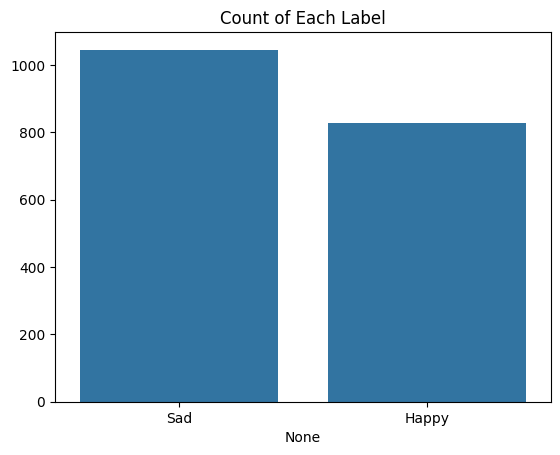

In [12]:
# 3. Data Exploration and Visualization
# 3.1 Find count of each label and plot bar graph
label_counts = pd.Series(labels).value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Count of Each Label')
plt.show()

#### Visualize sample audio signal using librosa

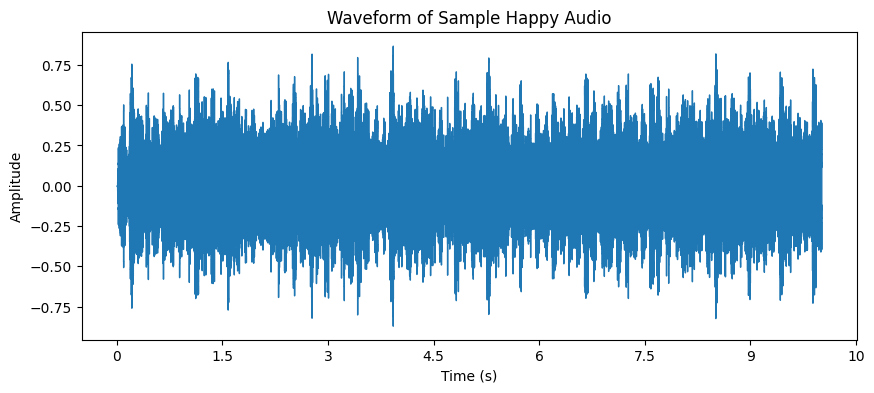

In [13]:
#sample audio file
sample_audio, sr_sample = librosa.load(file_paths[0], sr=None)

# Plot the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(sample_audio, sr=sr_sample)
plt.title('Waveform of Sample Happy Audio')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

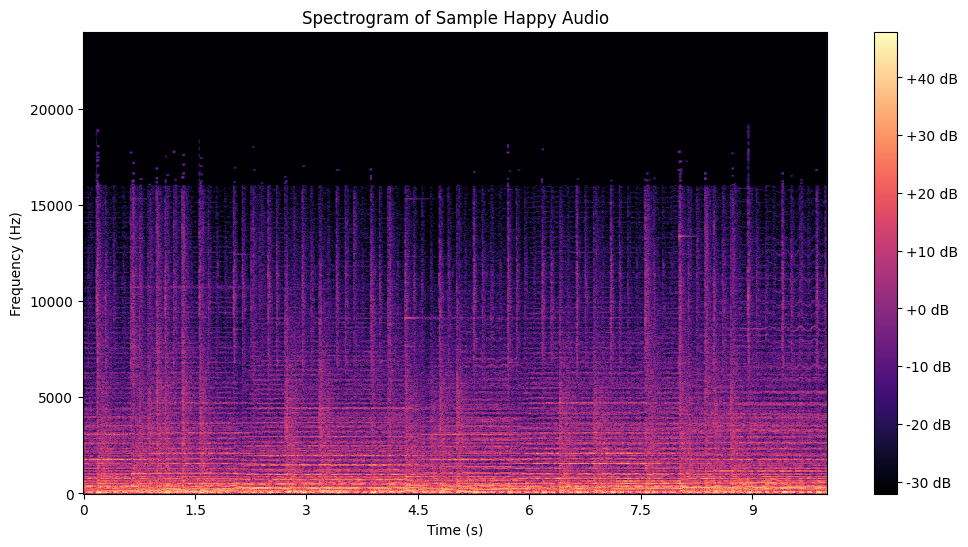

In [14]:
# Compute and plot spectrogram for the sample audio
S = librosa.stft(sample_audio)
S_db = librosa.amplitude_to_db(abs(S))

plt.figure(figsize=(12, 6))
librosa.display.specshow(S_db, sr=sr_sample, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format="%+2.0f dB")
plt.title('Spectrogram of Sample Happy Audio')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

## Preprocess Audio Files (Skip Non-10-Second Files)

### **Stage 3:** Feature extraction (2 points)
Extract audio features such as:



*  MFCCs
*  Mel Spectrogram
*   Zero Crossing Rate
* etc





In [16]:
# Feature extraction function for music classification
def extract_music_features(file, n_mfcc=40):
    # Load audio file
    y, sr = librosa.load(file, sr=None)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc = np.mean(mfcc.T, axis=0)  # Mean over time

    # Extract Chromagram
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma.T, axis=0)  # Mean over time

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast.T, axis=0)  # Mean over time

    # Extract Zero Crossing Rate (ZCR)
    zcr = librosa.feature.zero_crossing_rate(y=y)
    zcr = np.mean(zcr.T, axis=0)  # Mean over time

    # Extract Root Mean Square (RMS) Energy
    rms = librosa.feature.rms(y=y)
    rms = np.mean(rms.T, axis=0)  # Mean over time

    # Extract Spectral Bandwidth
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_bandwidth = np.mean(spectral_bandwidth.T, axis=0)  # Mean over time

    # Concatenate features
    features = np.hstack([mfcc, chroma, spectral_contrast, zcr, rms, spectral_bandwidth])
    return features

In [17]:

# Extract features for all files
features = [extract_music_features(file) for file in file_paths]
X = np.array(features)
y = np.array(labels)

# Encode Labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)

<ipython-input-16-006ff1d57534>:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.10/dist-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
<ipython-input-16-006ff1d57534>:4: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file, sr=None)
/usr/local/lib/python3.10/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.10/dist-packages/lib

In [18]:
print(f"Feature shape: {X.shape}, Label shape: {y.shape}")

Feature shape: (1873, 62), Label shape: (1873,)


## Scaling Features
It’s a good practice to scale the features before feeding them into the model to ensure that all features are on a similar scale, especially since audio features can vary in magnitude:

In [19]:
from sklearn.preprocessing import StandardScaler

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(f"Feature shape: {X.shape}, Label shape: {y.shape}")

Feature shape: (1873, 62), Label shape: (1873,)


## Build Model

In [20]:
# 6. Define CNN Model with Conv1d
class EmotionCNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(EmotionCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(16)  # Batch normalization after conv1
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.bn2 = nn.BatchNorm1d(32)  # Batch normalization after conv1
        self.conv3 = nn.Conv1d(32, 64, kernel_size=3, padding=1)  # Third convolution layer
        self.relu3 = nn.ReLU()
        self.bn3 = nn.BatchNorm1d(64)  # Batch normalization after conv1

        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)


        # Corrected flattened size after convolution and pooling
        # self.flatten_size = 32 * 29  # 32 channels, sequence length 29
        # Update flattened size based on the output shape
        self.flatten_size = 32 * 31  # Correct flattened size
        # self.flatten_size = 64 * 7

        self.fc1 = nn.Linear(self.flatten_size, 128)  # Updated size
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.6)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor before passing to fully connected layers
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

In [21]:
model = EmotionCNN(input_size=X.shape[1], num_classes=2)

In [22]:
print(model)

EmotionCNN(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu3): ReLU()
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=992, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.6, inplace=False)
  (relu): ReLU()
)


### **Stage 4:** Train the model  (4 points)


In [23]:
# 4.1 Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training shape: {X_train.shape}, Validation shape: {X_val.shape}")

Training shape: (1498, 62), Validation shape: (375, 62)


In [24]:
# 4.2 Create Dataset and DataLoader
class AudioDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_dataset = AudioDataset(X_train, y_train)
val_dataset = AudioDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [25]:
def get_conv_output_shape(model, input_size):
    with torch.no_grad():
        x = torch.zeros(1, 1, input_size)  # (batch_size, channels, sequence_length)
        x = model.conv1(x)
        x = model.conv2(x)
        x = model.pool(x)
        return x.size()

input_size = X.shape[1]  # Length of the input feature vector
output_shape = get_conv_output_shape(model, input_size)
print("Output shape after conv layers:", output_shape)

Output shape after conv layers: torch.Size([1, 32, 31])


In [26]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Add weight_decay

In [27]:
# 6.1 Training
def train(model, train_loader, val_loader, epochs, device):
    train_acc, val_acc = [], []
    model.to(device)  # Ensure the model is on the correct device (GPU/CPU)

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        # Training loop
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Move data to device
            X_batch = X_batch.unsqueeze(1)  # Reshape to (batch_size, 1, sequence_length)

            optimizer.zero_grad()
            outputs = model(X_batch)  # Forward pass
            loss = criterion(outputs, y_batch)  # Calculate loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Optimize weights

            # Calculate accuracy
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_acc.append(correct / total)

        # Validation loop
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                X_batch = X_batch.unsqueeze(1)  # Reshape to (batch_size, 1, sequence_length)

                outputs = model(X_batch)  # Forward pass
                _, preds = torch.max(outputs, 1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        val_acc.append(correct / total)
        print(f"Epoch {epoch+1}, Train Acc: {train_acc[-1]:.4f}, Val Acc: {val_acc[-1]:.4f}")

    return train_acc, val_acc


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [28]:
epoch_n=7
train_acc, val_acc = train(model, train_loader, val_loader,epoch_n,device)

Epoch 1, Train Acc: 0.6762, Val Acc: 0.7680
Epoch 2, Train Acc: 0.7837, Val Acc: 0.7893
Epoch 3, Train Acc: 0.8111, Val Acc: 0.8053
Epoch 4, Train Acc: 0.8391, Val Acc: 0.8427
Epoch 5, Train Acc: 0.8585, Val Acc: 0.8507
Epoch 6, Train Acc: 0.8625, Val Acc: 0.8507
Epoch 7, Train Acc: 0.8912, Val Acc: 0.8453


## Train Accuracy Plot
Shows how the training and validation loss evolve over epochs, helping identify overfitting or underfitting.

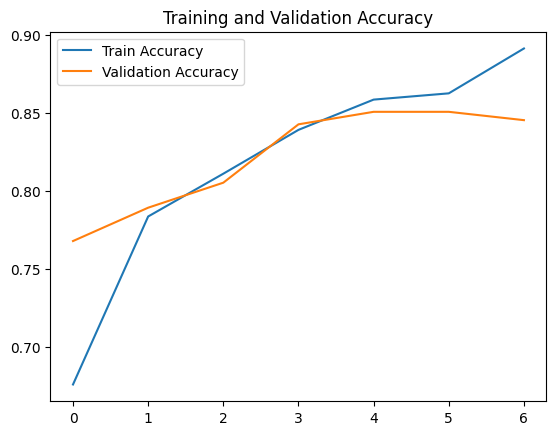

In [29]:
# 6.1 Plot Training and Validation Accuracy
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()
##loss is not captured in cnn train loop so cannot plot loss

### **Stage 5:** Kaggle Testset predictions (2 points)



*   Load the test set and extract the features of the .wav files
*   Using the trained model get the predicions on the test set
*   Finally, upload your predictions to the kaggle



In [30]:
# 6.2. Kaggle Test Predictions
model.eval()

def load_test_data(test_path, max_duration=10):
    files = [os.path.join(test_path, f) for f in os.listdir(test_path) if f.endswith('.wav')]
    features = [extract_music_features(file) for file in files]  # Ensure this extracts features as expected
    return np.array(features), files

test_path = '/content/Test/Test/'
X_test, test_files = load_test_data(test_path)

# Transform the unseen (test) data using the same scaler
# Only transform, do not fit again as we did with train data same operations to be applied on test data as well
X_test_scaled = scaler.transform(X_test)

# Convert the test data to a tensor
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Ensure the input has the right shape (batch_size, 1, sequence_length)
X_test_tensor = X_test_tensor.unsqueeze(1)  # Adding the channel dimension (1)

# Move test data to the same device as the model
X_test_tensor = X_test_tensor.to(device)

# Get predictions
with torch.no_grad():  # Disable gradient computation for inference
    preds = model(X_test_tensor)
    _, predicted_labels = torch.max(preds, 1)

# Get predicted labels and associate with file names if needed
predicted_labels = predicted_labels.cpu().numpy()  # Move predictions to CPU if on GPU
predicted_files = list(zip(test_files, predicted_labels))  # Associate file paths with predictions


/usr/local/lib/python3.10/dist-packages/librosa/core/pitch.py:101: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


In [31]:
#6.3 submission file
submission = pd.DataFrame({'File Name': [os.path.basename(f) for f in test_files],
                           'Target': encoder.inverse_transform(predicted_labels)})
submission.to_csv('submission.csv', index=False)
print("Submission file created.")

Submission file created.


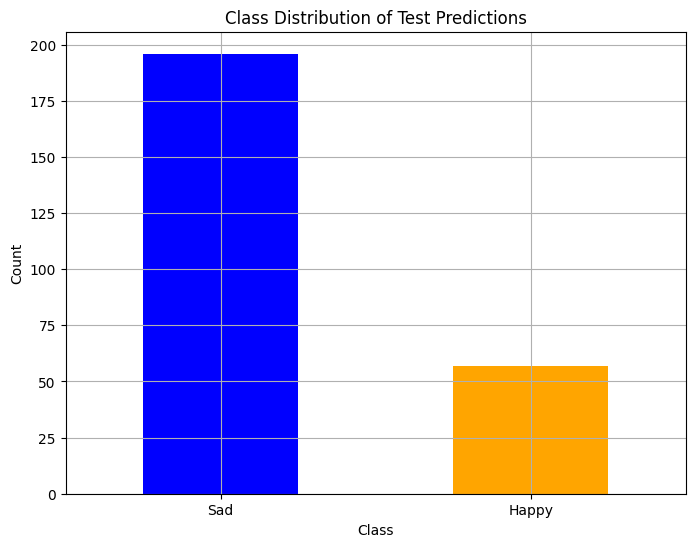

Unique Labels: Index(['Sad', 'Happy'], dtype='object', name='Target')
Label Counts: [196  57]


In [32]:
label_counts = submission['Target'].value_counts()

# Plot a bar plot
plt.figure(figsize=(8, 6))
label_counts.plot(kind='bar', color=['blue', 'orange'])
plt.title('Class Distribution of Test Predictions')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()
print(f"Unique Labels: {label_counts.index}")
print(f"Label Counts: {label_counts.values}")